In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.preprocessing import image
from PIL import Image
import shap

# Import the specific models and their unique preprocessing functions
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_prep, decode_predictions as vgg_decode
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as res_prep, decode_predictions as res_decode
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input as inc_prep, decode_predictions as inc_decode

# ---------------------------------------------------------
# 1. MODEL CONFIGURATION
# ---------------------------------------------------------
MODEL_CONFIG = {
    'vgg16': {
        'class': VGG16,
        'target_size': (224, 224),
        'preprocess': vgg_prep,
        'decode': vgg_decode,
        'last_conv_layer': 'block5_conv3'
    },
    'resnet50': {
        'class': ResNet50,
        'target_size': (224, 224),
        'preprocess': res_prep,
        'decode': res_decode,
        'last_conv_layer': 'conv5_block3_out'
    },
    'inceptionv3': {
        'class': InceptionV3,
        'target_size': (299, 299),
        'preprocess': inc_prep,
        'decode': inc_decode,
        'last_conv_layer': 'mixed10'
    }
}

# ---------------------------------------------------------
# 2. HELPER CLASSES & FUNCTIONS
# ---------------------------------------------------------

class CustomExplainer:
    """
    Your custom SHAP/Gradient explainer class.
    Calculates gradients of the output w.r.t the input image.
    """
    def __init__(self, model):
        self.model = model

    def shap_values(self, images):
        # Convert NumPy array to TensorFlow tensor if it isn't already
        images_tensor = tf.convert_to_tensor(images, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            tape.watch(images_tensor)
            predictions = self.model(images_tensor)
            # Average over batch (or classes depending on shape, logic preserved from snippet)
            loss = tf.reduce_mean(predictions, axis=0) 
            
        gradients = tape.gradient(loss, images_tensor)
        return gradients.numpy()

def load_and_prep_image(file_path, target_size, preprocess_func):
    """
    Loads an image, resizes it, and applies specific model preprocessing.
    """
    img = Image.open(file_path).convert('RGB')
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    
    # Original for visualization (0-255)
    original_img = img_array.astype('uint8')
    
    # Preprocessed for model
    input_tensor = np.expand_dims(img_array, axis=0)
    input_tensor = preprocess_func(input_tensor)
    
    return original_img, input_tensor

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates the Grad-CAM heatmap.
    """
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ---------------------------------------------------------
# 3. MAIN EXPLANATION FUNCTION
# ---------------------------------------------------------

def explain_prediction(img_path, model_name='vgg16'):
    """
    Main function to load a model, predict, and generate Grad-CAM, LIME, and SHAP explanations.
    """
    
    # 1. SETUP
    model_name = model_name.lower()
    if model_name not in MODEL_CONFIG:
        raise ValueError(f"Model {model_name} not supported. Choose from {list(MODEL_CONFIG.keys())}")
    
    print(f"\n{'='*20}")
    print(f"Loading {model_name.upper()} Model")
    print(f"{'='*20}")
    
    config = MODEL_CONFIG[model_name]
    
    # Load Model (Pre-trained on ImageNet)
    model = config['class'](weights='imagenet')

    # Load and Preprocess Image
    original_img, img_tensor = load_and_prep_image(
        img_path, 
        config['target_size'], 
        config['preprocess']
    )

    # Get Prediction
    preds = model.predict(img_tensor)
    top_pred = config['decode'](preds, top=1)[0][0]
    print(f"Top prediction: {top_pred[1]} ({top_pred[2]*100:.2f}%)")

    # ---------------------------------------------------------
    # 2. GRAD-CAM
    # ---------------------------------------------------------
    print("Generating Grad-CAM...")
    heatmap = make_gradcam_heatmap(img_tensor, model, config['last_conv_layer'])

    # Resize heatmap to match original image size
    heatmap_resized = cv2.resize(heatmap, config['target_size'])
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Superimpose
    # Note: OpenCV uses BGR, Matplotlib uses RGB. 
    superimposed_img = heatmap_colored * 0.6 + original_img[:, :, ::-1] 
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 3. LIME
    # ---------------------------------------------------------
    print("Generating LIME explanation...")
    explainer_lime = lime_image.LimeImageExplainer()

    # Define prediction function specifically for LIME 
    def predict_fn_lime(images):
        processed_images = []
        for i in images:
            x = config['preprocess'](i.copy()) 
            processed_images.append(x)
        return model.predict(np.array(processed_images))

    explanation = explainer_lime.explain_instance(
        original_img.astype('double'), 
        predict_fn_lime, 
        top_labels=1, 
        hide_color=0, 
        num_samples=500 # Reduced samples for speed, increase to 1000 for better quality
    )

    temp_lime, mask_lime = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=False, 
        num_features=10, 
        hide_rest=False
    )
    lime_img = mark_boundaries(temp_lime / 255.0, mask_lime)

    # ---------------------------------------------------------
    # 4. SHAP (Custom Gradient Explainer)
    # ---------------------------------------------------------
    print("Generating SHAP (Gradient) explanation...")
    
    # Instantiate your CustomExplainer with the current model
    explainer = CustomExplainer(model)
    
    # Get SHAP values for the specific input image tensor
    shap_values = explainer.shap_values(img_tensor)

    # ---------------------------------------------------------
    # 5. VISUALIZATION
    # ---------------------------------------------------------
    
    # Part 1: Original, Grad-CAM, LIME
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title(f"Original ({model_name.upper()})")
    plt.axis('off')

    # Grad-CAM
    plt.subplot(1, 3, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM\nLayer: {config['last_conv_layer']}")
    plt.axis('off')

    # LIME
    plt.subplot(1, 3, 3)
    plt.imshow(lime_img)
    plt.title("LIME Explanation")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Part 2: SHAP Visualization
    # SHAP image_plot generates its own complex figure, so we plot it separately below
    print("Displaying SHAP Plot...")
    
    # Note: img_tensor is preprocessed (normalized/centered), so colors might look 
    # different (e.g., BGR vs RGB) compared to the original image.
    shap.image_plot([shap_values], img_tensor) 




Loading VGG16 Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
Top prediction: electric_ray (27.41%)
Generating Grad-CAM...
Generating LIME explanation...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_536']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━

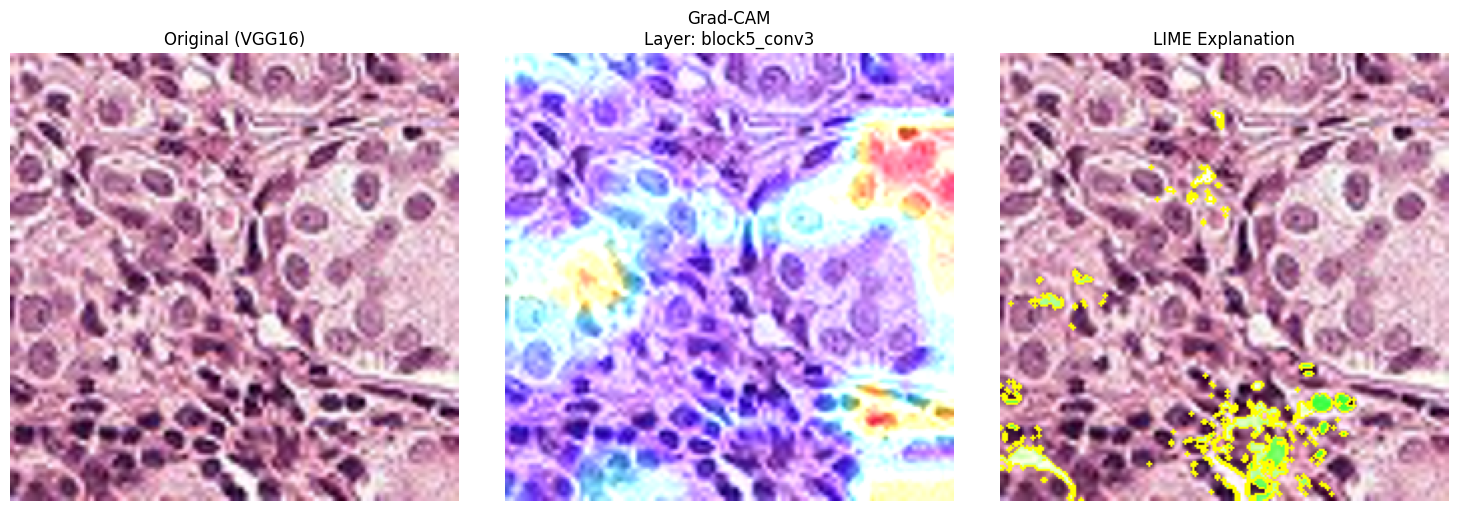

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..151.061].


Displaying SHAP Plot...


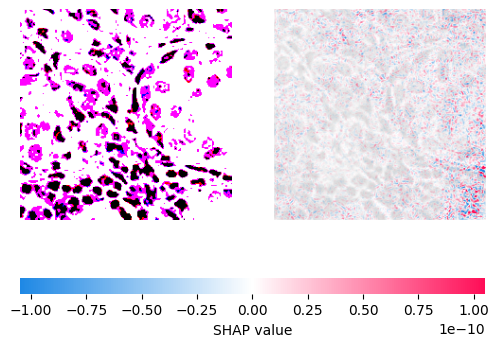


Loading RESNET50 Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Top prediction: stole (67.02%)
Generating Grad-CAM...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_559']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Generating LIME explanation...


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━

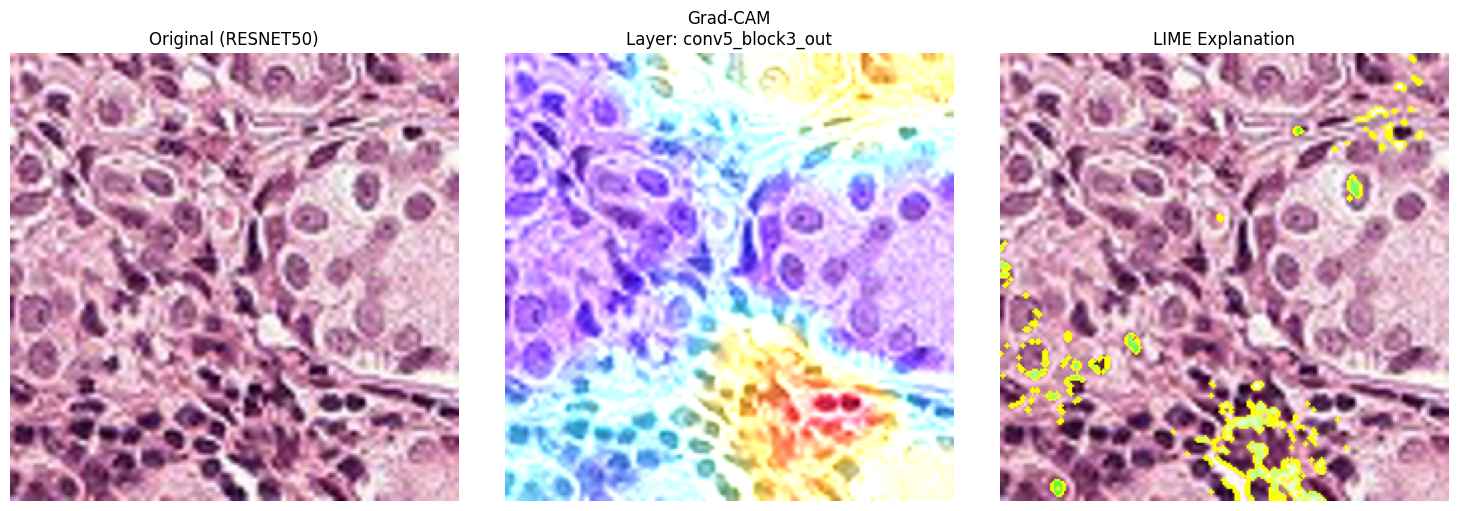

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..151.061].


Displaying SHAP Plot...


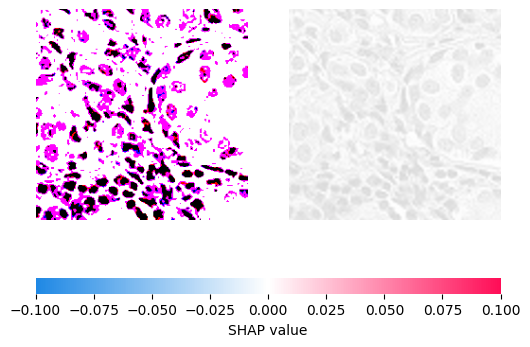


Loading INCEPTIONV3 Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Top prediction: velvet (41.94%)
Generating Grad-CAM...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_736']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


Generating LIME explanation...


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━

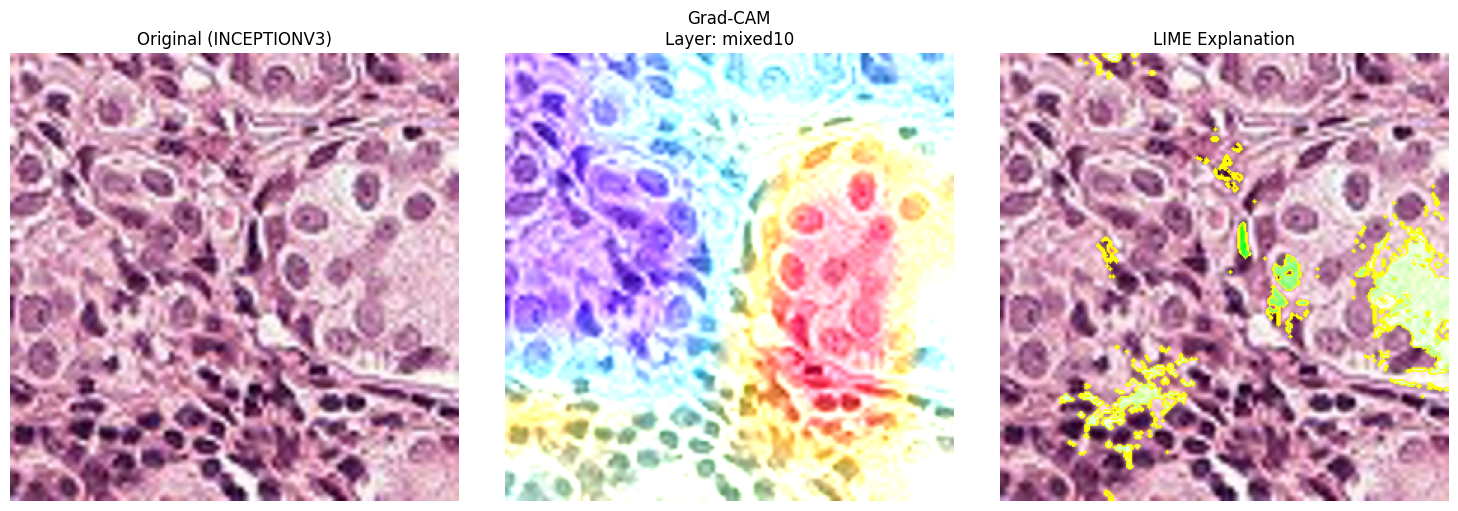

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Displaying SHAP Plot...


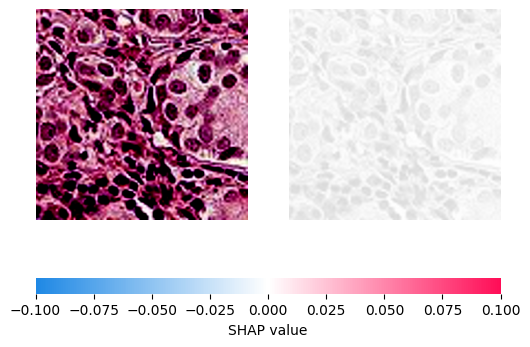

In [4]:
# ---------------------------------------------------------
# EXAMPLE USAGE
# ---------------------------------------------------------

# Define your image path
img_path = "/kaggle/input/datasets/liquidicalpants/cancer-test-data-for-validation/Test Data For Validation/1/Normal/2f09dbde7a4884a55714ac85a9804a587a717423.tif"

# 1. Run with VGG16
explain_prediction(img_path, model_name='vgg16')

# 2. Run with ResNet50
explain_prediction(img_path, model_name='resnet50')

# 3. Run with InceptionV3
explain_prediction(img_path, model_name='inceptionv3')